In [1]:
import sys
import importlib.util
import pickle
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA

In [2]:
#workaround for plotters import 

spec = importlib.util.spec_from_file_location("plotters", "/home/wuhlmann/BA/repo/lamah-ce_lstm/analysis/plotting/cell_state_plotters.py")
plotters = importlib.util.module_from_spec(spec)
sys.modules["plotters"] = plotters
spec.loader.exec_module(plotters)

from plotters import plot_cell_state_2d, plot_cell_state_3d

In [3]:
# full_q

full_q_states = []

with open("/home/wuhlmann/BA/data/processed_data/cell_states/full_q_512_3011_185525_cell_states_116.p", "rb") as f:
	full_q_states.append(pickle.load(f))

with open("/home/wuhlmann/BA/data/processed_data/cell_states/full_q_512_3011_185525_cell_states_117.p", "rb") as f:
	full_q_states.append(pickle.load(f))
	
with open("/home/wuhlmann/BA/data/processed_data/cell_states/full_q_512_3011_185525_cell_states_410.p", "rb") as f: 
	full_q_states.append(pickle.load(f))

with open("/home/wuhlmann/BA/data/processed_data/cell_states/full_q_512_3011_185525_cell_states_553.p", "rb") as f: 
	full_q_states.append(pickle.load(f))

# q_filter 

q_filter_states = []

with open("/home/wuhlmann/BA/data/processed_data/cell_states/512_batch_size_2711_095750_cell_states_116.p", "rb") as f:
	full_q_states.append(pickle.load(f))

with open("/home/wuhlmann/BA/data/processed_data/cell_states/512_batch_size_2711_095750_cell_states_117.p", "rb") as f:
	full_q_states.append(pickle.load(f))

with open("/home/wuhlmann/BA/data/processed_data/cell_states/512_batch_size_2711_095750_cell_states_410.p", "rb") as f: 
	 q_filter_states.append(pickle.load(f))

with open("/home/wuhlmann/BA/data/processed_data/cell_states/512_batch_size_2711_095750_cell_states_553.p", "rb") as f: 
	 q_filter_states.append(pickle.load(f))


In [4]:
mode = "normal"

### Experimentel cell state plots of single basins

May be interesting as a further investigation, if there is time. 

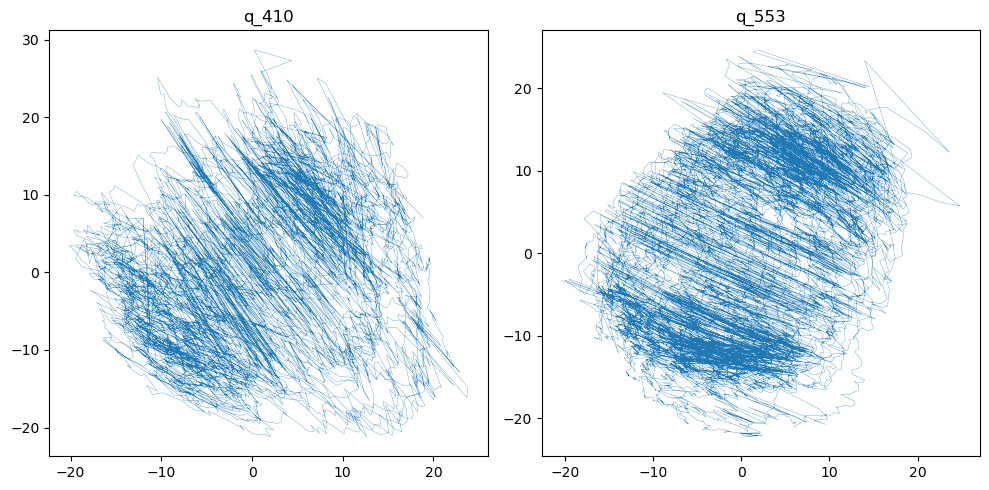

In [5]:
fig, axs = plt.subplots(1,2, figsize=(10,5))

for ax, array, title in zip(
	axs.ravel(),
	list(map(lambda x: x[mode], full_q_states[-2:])),
	["q_410", "q_553"]):
	
	# Assign every 365 points the same color, to look for seasonal patterns.
	point_colors = np.arange(len(array)) // 365

	plot_cell_state_2d(
		cell_state_array=array,
		ax=ax,
		title=title,
		connect=True, 
		linewidth=0.2
	)

plt.tight_layout()

### MDS of Average cell state plots of all basins

In [6]:
with open("/home/wuhlmann/BA/data/processed_data/cell_states/512_batch_size_2711_095750_cell_states_mds.p", "rb") as f: 
	filter_means_mds = pickle.load(f)
	
with open("/home/wuhlmann/BA/data/processed_data/cell_states/full_q_512_3011_185525_cell_states_mds.p", "rb") as f: 
	full_means_mds = pickle.load(f)


In [7]:
strata_ids = pd.read_table("/home/wuhlmann/BA/data/processed_data/test_splits/strata_ids_incl_651.txt", header=0, sep=",")
strata_ids.set_index("ID", inplace=True)

In [8]:
lamah_gdf = gpd.read_file("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/B_basins_intermediate_all/3_shapefiles/Basins_B.shp")
lamah_gdf.set_index("ID", inplace=True)
lamah_gdf["strata"] = strata_ids["0"]
lamah_gdf.sort_index(ascending=True, inplace=True)

0 basins could not be assined | (array([0, 1, 2], dtype=int32), array([244, 417, 198]))
0 basins could not be assined | (array([0, 1, 2], dtype=int32), array([231, 431, 197]))
0 basins could not be assined | (array([0, 1, 2], dtype=int32), array([221, 480, 158]))
0 basins could not be assined | (array([0, 1, 2], dtype=int32), array([318,   1, 540]))


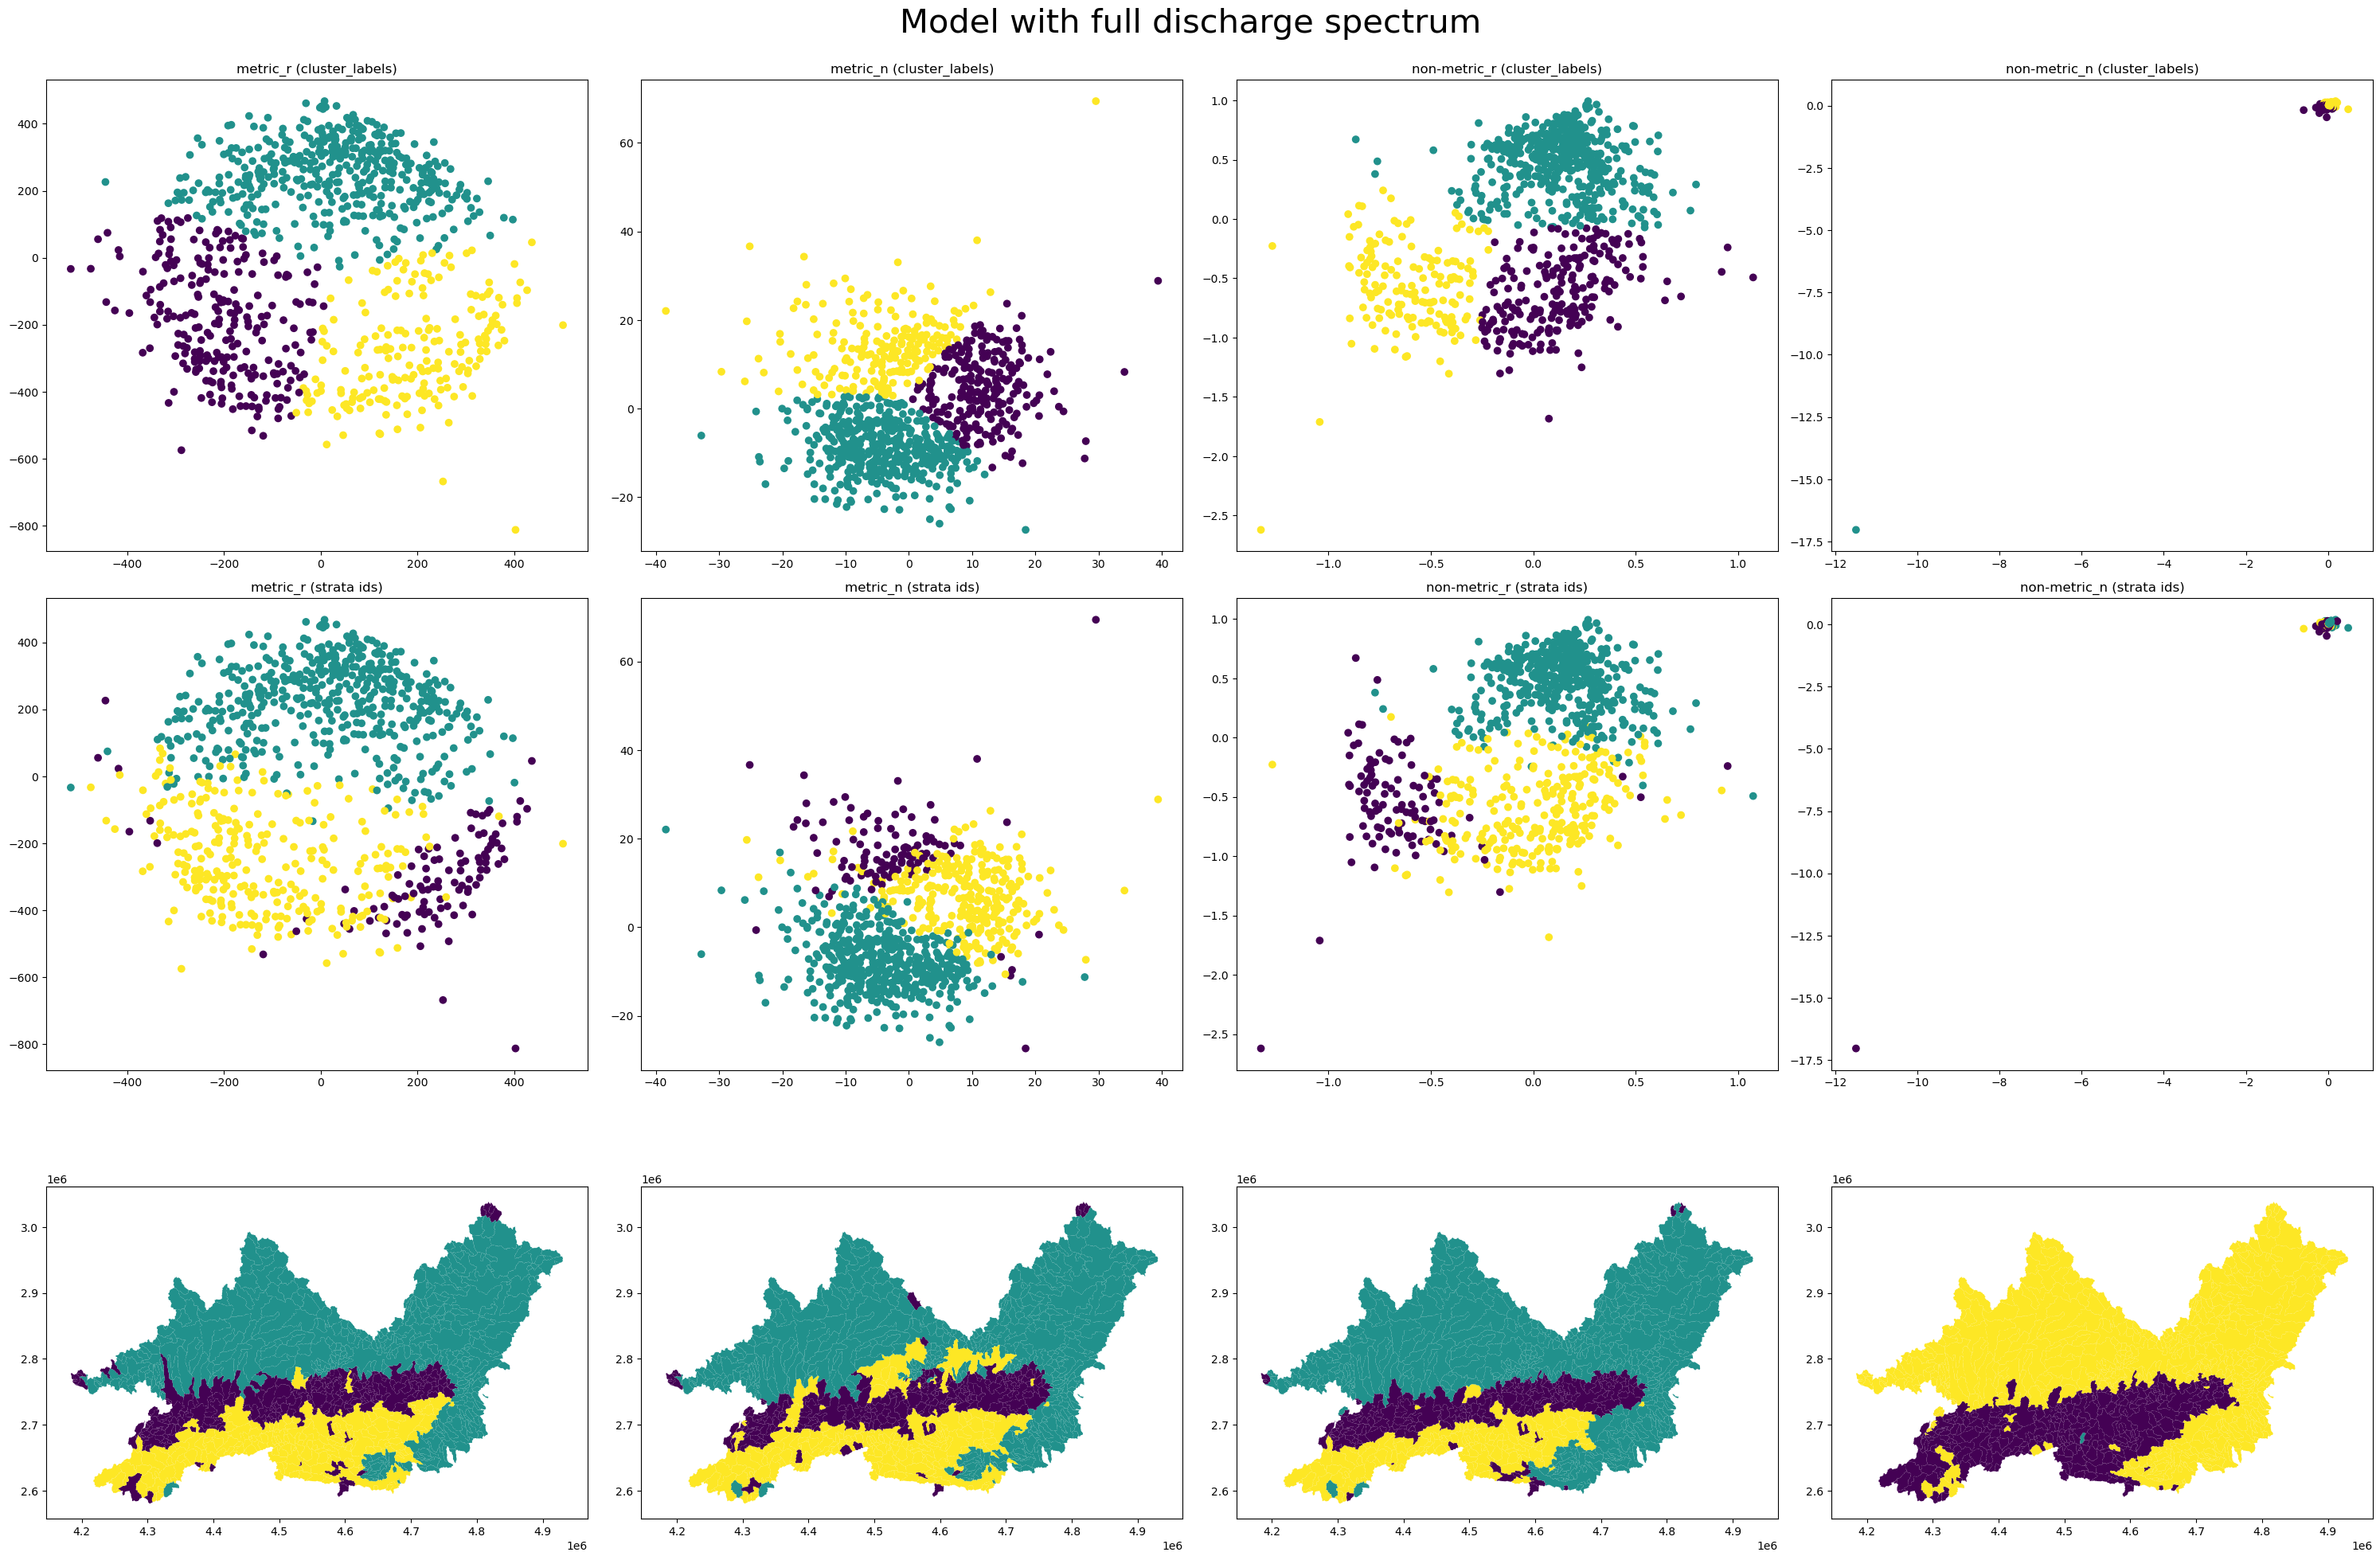

In [35]:
k_means = KMeans(3, random_state=1277, max_iter=100)

fig, axs = plt.subplots(3,4, figsize=(30,20))
axs = axs.ravel()
fig.suptitle("Model with full discharge spectrum", fontsize=30, y=1)

for i, array, title in zip(
	[0,1,2,3],
	[full_means_mds["metric"][m] for m in ["raw", "normal"]] + [full_means_mds["non-metric"][m] for m in ["raw", "normal"]],
	["metric_r", "metric_n", "non-metric_r", "non-metric_n"]
):
	
	cluster = k_means.fit_predict(array)

	print(f"{len(cluster[cluster==-1])} basins could not be assined | {np.unique(cluster, return_counts=True)}")

	lamah_gdf[f"agglo_{title}"] = cluster		
	plot_cell_state_2d(array[cluster!=-1], ax=axs[i], title=f"{title} (cluster_labels)", c=cluster[cluster !=-1])
	plot_cell_state_2d(array, ax=axs[i+4], title=f"{title} (strata ids)", c=strata_ids["0"])
	
	lamah_gdf.plot(ax=axs[i+8], column=f"agglo_{title}")

fig.savefig("/home/wuhlmann/BA/repo/lamah-ce_lstm/results/full_q_average_state_mds.png", dpi=300)
plt.tight_layout()

0 basins could not be assined | (array([0, 1, 2], dtype=int32), array([467, 183, 209]))
0 basins could not be assined | (array([0, 1, 2], dtype=int32), array([347, 251, 261]))
0 basins could not be assined | (array([0, 1, 2], dtype=int32), array([513, 125, 221]))
0 basins could not be assined | (array([0, 1, 2], dtype=int32), array([493,   1, 365]))


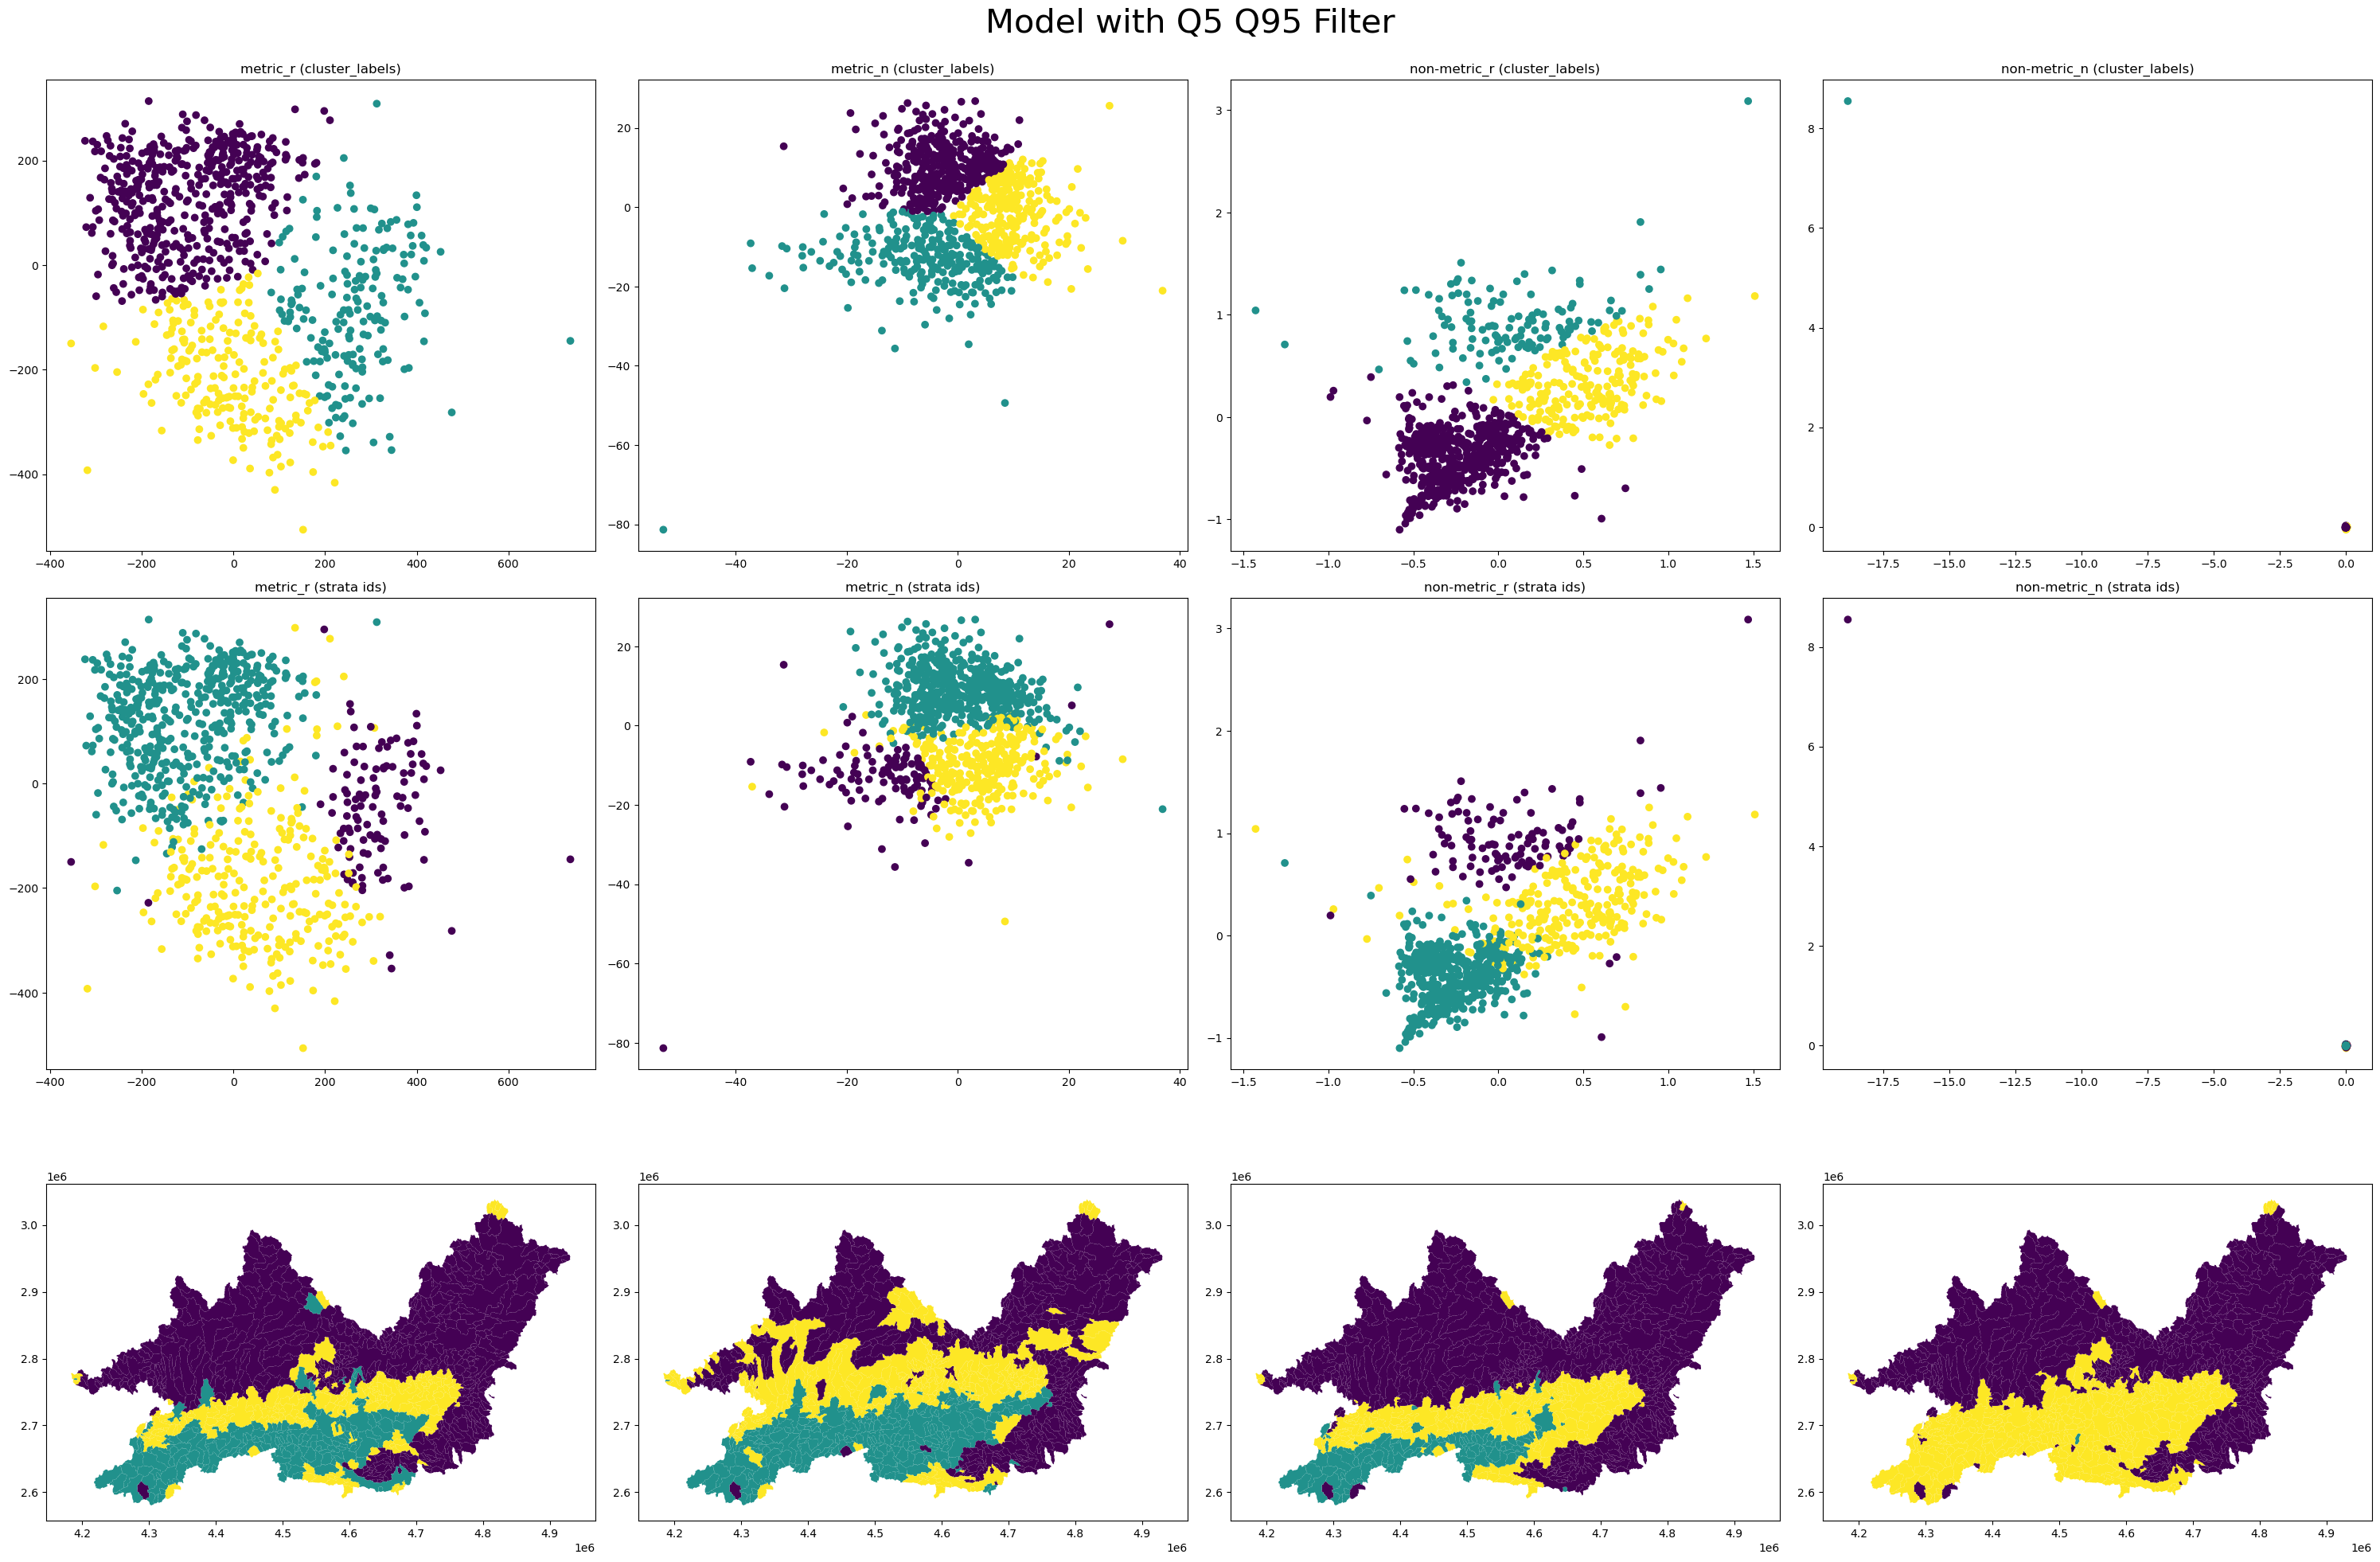

In [34]:
k_means = KMeans(3, random_state=1, max_iter=100)
agglo = AgglomerativeClustering(3, linkage="ward")

fig, axs = plt.subplots(3,4, figsize=(30,20))
axs = axs.ravel()
fig.suptitle("Model with Q5 Q95 Filter", fontsize=30, y=1)

for i, array, title in zip(
	[0,1,2,3],
	[filter_means_mds["metric"][m] for m in ["raw", "normal"]] + [filter_means_mds["non-metric"][m] for m in ["raw", "normal"]],
	["metric_r", "metric_n", "non-metric_r", "non-metric_n"]
):
	
	#cluster = agglo.fit_predict(array)
	cluster = k_means.fit_predict(array)

	print(f"{len(cluster[cluster==-1])} basins could not be assined | {np.unique(cluster, return_counts=True)}")

	lamah_gdf[f"agglo_{title}"] = cluster		
	plot_cell_state_2d(array[cluster!=-1], ax=axs[i], title=f"{title} (cluster_labels)", c=cluster[cluster !=-1])
	plot_cell_state_2d(array, ax=axs[i+4], title=f"{title} (strata ids)", c=strata_ids["0"])

	lamah_gdf.plot(ax=axs[i+8], column=f"agglo_{title}")

fig.savefig("/home/wuhlmann/BA/repo/lamah-ce_lstm/results/q_filter_average_state_mds.png", dpi=300)
plt.tight_layout()

### Check if clusters are also present in original cell state

In [11]:
with open("/home/wuhlmann/BA/data/processed_data/cell_states/512_batch_size_2711_095750_cell_states.p", "rb") as f: 
	filter_raw_cell_states = pickle.load(f)

filter_raw_cell_states = dict(sorted(filter_raw_cell_states.items(), key=lambda item: int(item[0])))

with open("/home/wuhlmann/BA/data/processed_data/cell_states/full_q_512_3011_185525_cell_states.p", "rb") as f: 
	full_raw_cell_states = pickle.load(f)

full_raw_cell_states = dict(sorted(full_raw_cell_states.items(), key=lambda item: int(item[0])))

In [ ]:
filter_r_cs_array = np.vstack([filter_raw_cell_states[b]["c_mean"] for b in filter_raw_cell_states.keys()])

full_r_cs_array = np.vstack([full_raw_cell_states[b]["c_mean"] for b in full_raw_cell_states.keys()])

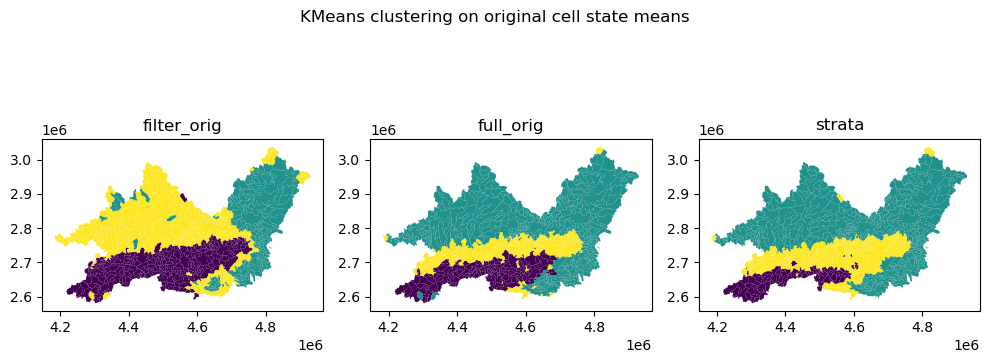

In [33]:
kmeans = KMeans(n_clusters=3, random_state=1277, max_iter=100)

fig, axs = plt.subplots(1,3, figsize=(10,10))

for ax, array, name in zip(axs[:2], [filter_r_cs_array, full_r_cs_array], ["filter_orig", "full_orig"]):

	cluster = kmeans.fit_predict(array)

	lamah_gdf[name] = cluster

	lamah_gdf.plot(column=name, ax=ax)
	ax.set_title(name)

lamah_gdf.plot(column="strata", ax=axs[2])
axs[2].set_title("strata")

fig.suptitle("KMeans clustering on original cell state means", y=0.7)
fig.savefig("/home/wuhlmann/BA/repo/lamah-ce_lstm/results/original_cell_state_means_cluster.png", dpi=300)
plt.tight_layout()



PCA and then k-means clustering, since clusters of stratas appear to be convex. hierch single linkage

we created a regional clustering at the beginning, which the model reproduced in some form. therefore the model represents some regional pattern, which was not explicitly fed into it, but learned from the same + more (dyn) basins characteristics 

### PCA of average cell states of all basins.

Maybe do the PCA on all cell states of the day of predicion, since they hold more information than the average. 

In [ ]:
with open("/home/wuhlmann/BA/data/processed_data/cell_states/512_batch_size_2711_095750_cell_states.p", "rb") as f: 
	filtered_raw_cell_states = pickle.load(f)
	
filtered_raw_cell_states = dict(sorted(filtered_raw_cell_states.items(), key=lambda item: int(item[0])))

with open("/home/wuhlmann/BA/data/processed_data/cell_states/full_q_512_3011_185525_cell_states.p", "rb") as f: 
	full_raw_cell_states = pickle.load(f)

# Since the cell state extraction is done in parallel, the results dict is unorded. Sort by basin id. 
full_raw_cell_states = dict(sorted(full_raw_cell_states.items(), key=lambda item: int(item[0])))


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x15484c372380>>
Traceback (most recent call last):
  File "/home/wuhlmann/miniforge3/envs/lamah-ce_lstm/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


In [ ]:
from sklearn.decomposition import PCA 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

filter_num_PC_per_basin = {}
full_num_PC_per_basin = {}

pca_09 = PCA(n_components=0.9, random_state=1277)

for id in tqdm(full_raw_cell_states.keys()):
	
	pca_09.fit(scaler.fit_transform(filtered_raw_cell_states[id]["c_last"]))

	filter_num_PC_per_basin[id] = int(len(pca_09.explained_variance_))
	
	pca_09.fit(scaler.fit_transform(full_raw_cell_states[id]["c_last"]))

	full_num_PC_per_basin[id] = int(len(pca_09.explained_variance_))

100%|██████████| 859/859 [01:37<00:00,  8.84it/s]


In [ ]:
np.min(list(full_num_PC_per_basin.values()))

9

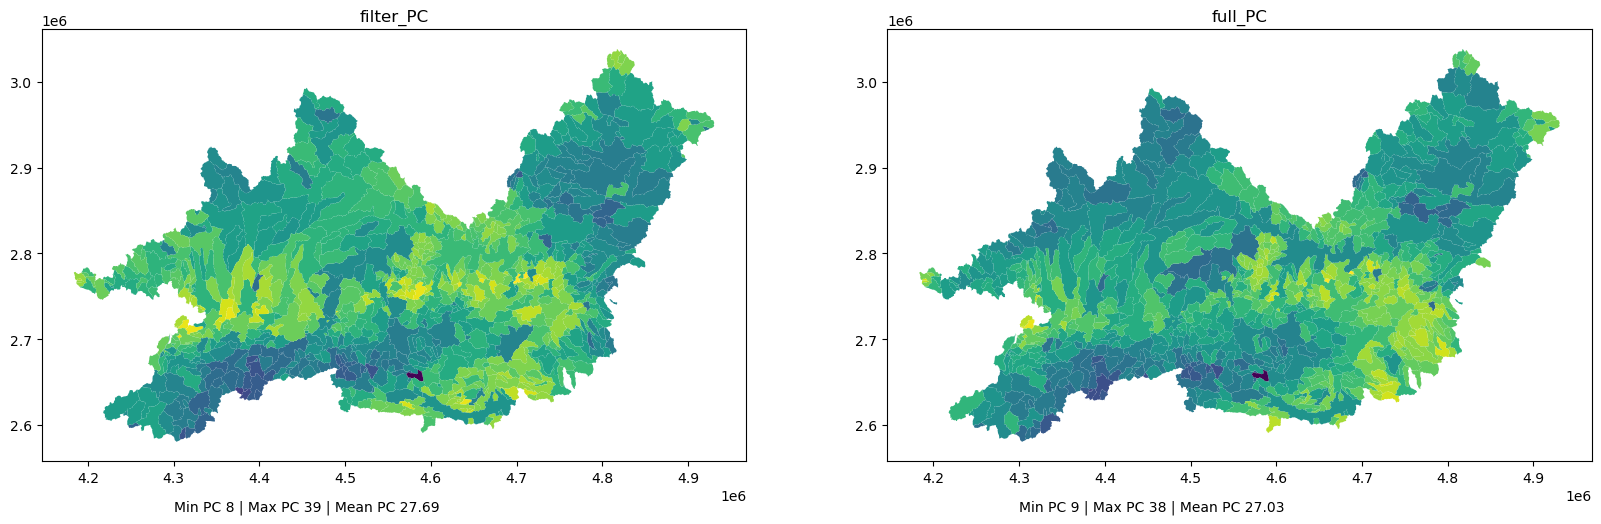

In [ ]:
fig, axs = plt.subplots(1,2, figsize=(20,10))

for ax, array, col in zip(axs, [filter_num_PC_per_basin, full_num_PC_per_basin], ["filter_PC", "full_PC"]):
	
	value_list = list(array.values())

	lamah_gdf[col] = value_list
	lamah_gdf.plot(column=col, ax=ax)
	ax.set_title(col)
	ax.text(x=4.3e6, y=2.5e6, s=f"Min PC {np.min(value_list)} | Max PC {np.max(value_list)} | Mean PC {np.mean(value_list):.2f}")

fig.savefig("/home/wuhlmann/BA/repo/lamah-ce_lstm/results/num_PC_per_basin.png", dpi=300)